In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import os

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
os.makedirs('images', exist_ok=True)

tickers = {
    'JPM': 'JP Morgan',
    'AAPL': 'Apple',
    'MSFT': 'Microsoft',
    'GOOGL': 'Google',
    'BRK-B': 'Berkshire Hathaway',
    'JNJ': 'Johnson & Johnson',
    'XOM': 'Exxon Mobil'
}

df = yf.download(list(tickers.keys()), start='2020-01-01', end='2024-12-31')['Close']
df.columns = [tickers[col] for col in df.columns]
df = df.fillna(method='ffill')
returns = df.pct_change().dropna()

mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252
risk_free_rate = 0.05

print("데이터 준비 완료!")
print(f"종목: {list(df.columns)}")

[*********************100%***********************]  7 of 7 completed

데이터 준비 완료!
종목: ['Apple', 'Berkshire Hathaway', 'Google', 'Johnson & Johnson', 'JP Morgan', 'Microsoft', 'Exxon Mobil']



C:\Users\playdata2\AppData\Local\Temp\ipykernel_5760\225432551.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [2]:
def portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate):
    returns = np.sum(mean_returns * weights)
    std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = (returns - risk_free_rate) / std
    return returns, std, sharpe

def neg_sharpe(weights, mean_returns, cov_matrix, risk_free_rate):
    return -portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate)[2]

def portfolio_variance(weights, cov_matrix):
    return np.dot(weights.T, np.dot(cov_matrix, weights))

print("함수 정의 완료!")

함수 정의 완료!


In [3]:
num_portfolios = 10000
num_assets = len(mean_returns)

results = np.zeros((3, num_portfolios))
weights_record = []

np.random.seed(42)
for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    weights_record.append(weights)

    p_returns, p_std, p_sharpe = portfolio_performance(
        weights, mean_returns, cov_matrix, risk_free_rate
    )
    results[0, i] = p_std
    results[1, i] = p_returns
    results[2, i] = p_sharpe

print(f"Monte Carlo 시뮬레이션 완료: {num_portfolios:,}개 포트폴리오")
print(f"최대 Sharpe Ratio: {results[2].max():.4f}")
print(f"최소 변동성: {results[0].min():.4f}")

Monte Carlo 시뮬레이션 완료: 10,000개 포트폴리오
최대 Sharpe Ratio: 0.8054
최소 변동성: 0.1856


In [4]:
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(num_assets))
init_weights = np.array([1/num_assets] * num_assets)

# 최대 Sharpe Ratio 포트폴리오
opt_sharpe = minimize(neg_sharpe, init_weights,
                      args=(mean_returns, cov_matrix, risk_free_rate),
                      method='SLSQP', bounds=bounds, constraints=constraints)

# 최소 변동성 포트폴리오
opt_vol = minimize(portfolio_variance, init_weights,
                   args=(cov_matrix,),
                   method='SLSQP', bounds=bounds, constraints=constraints)

max_sharpe_perf = portfolio_performance(opt_sharpe.x, mean_returns, cov_matrix, risk_free_rate)
min_vol_perf = portfolio_performance(opt_vol.x, mean_returns, cov_matrix, risk_free_rate)

print("=== 최대 Sharpe Ratio 포트폴리오 ===")
for i, stock in enumerate(df.columns):
    print(f"  {stock}: {opt_sharpe.x[i]*100:.1f}%")
print(f"  수익률: {max_sharpe_perf[0]*100:.2f}%, 변동성: {max_sharpe_perf[1]*100:.2f}%, Sharpe: {max_sharpe_perf[2]:.4f}")

print("\n=== 최소 변동성 포트폴리오 ===")
for i, stock in enumerate(df.columns):
    print(f"  {stock}: {opt_vol.x[i]*100:.1f}%")
print(f"  수익률: {min_vol_perf[0]*100:.2f}%, 변동성: {min_vol_perf[1]*100:.2f}%, Sharpe: {min_vol_perf[2]:.4f}")

=== 최대 Sharpe Ratio 포트폴리오 ===
  Apple: 60.7%
  Berkshire Hathaway: 0.0%
  Google: 19.7%
  Johnson & Johnson: 0.0%
  JP Morgan: 0.0%
  Microsoft: 2.8%
  Exxon Mobil: 16.8%
  수익률: 27.16%, 변동성: 26.87%, Sharpe: 0.8247

=== 최소 변동성 포트폴리오 ===
  Apple: 0.0%
  Berkshire Hathaway: 25.5%
  Google: 7.9%
  Johnson & Johnson: 58.9%
  JP Morgan: 0.0%
  Microsoft: 2.6%
  Exxon Mobil: 5.0%
  수익률: 10.32%, 변동성: 17.90%, Sharpe: 0.2974


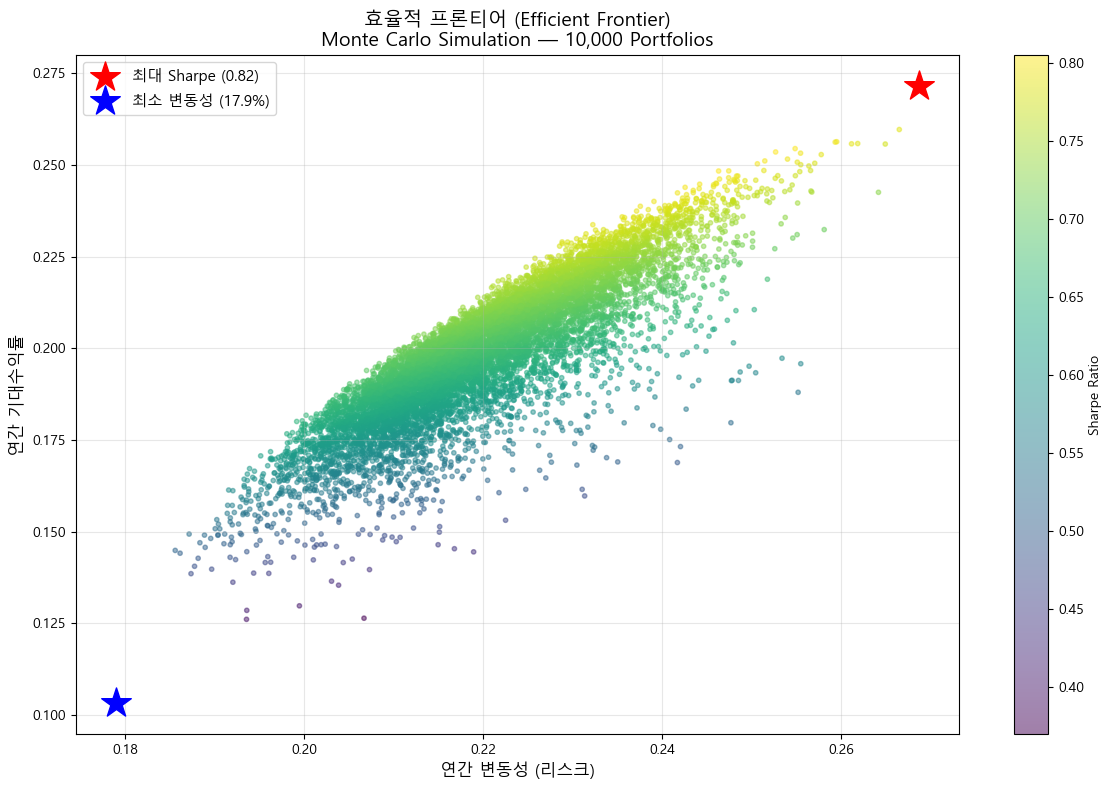

In [5]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(results[0], results[1],
                      c=results[2], cmap='viridis',
                      alpha=0.5, s=10)
plt.colorbar(scatter, label='Sharpe Ratio')

# 최대 Sharpe
plt.scatter(max_sharpe_perf[1], max_sharpe_perf[0],
            marker='*', color='red', s=500, zorder=5,
            label=f'최대 Sharpe ({max_sharpe_perf[2]:.2f})')

# 최소 변동성
plt.scatter(min_vol_perf[1], min_vol_perf[0],
            marker='*', color='blue', s=500, zorder=5,
            label=f'최소 변동성 ({min_vol_perf[1]*100:.1f}%)')

plt.xlabel('연간 변동성 (리스크)', fontsize=12)
plt.ylabel('연간 기대수익률', fontsize=12)
plt.title('효율적 프론티어 (Efficient Frontier)\nMonte Carlo Simulation — 10,000 Portfolios', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

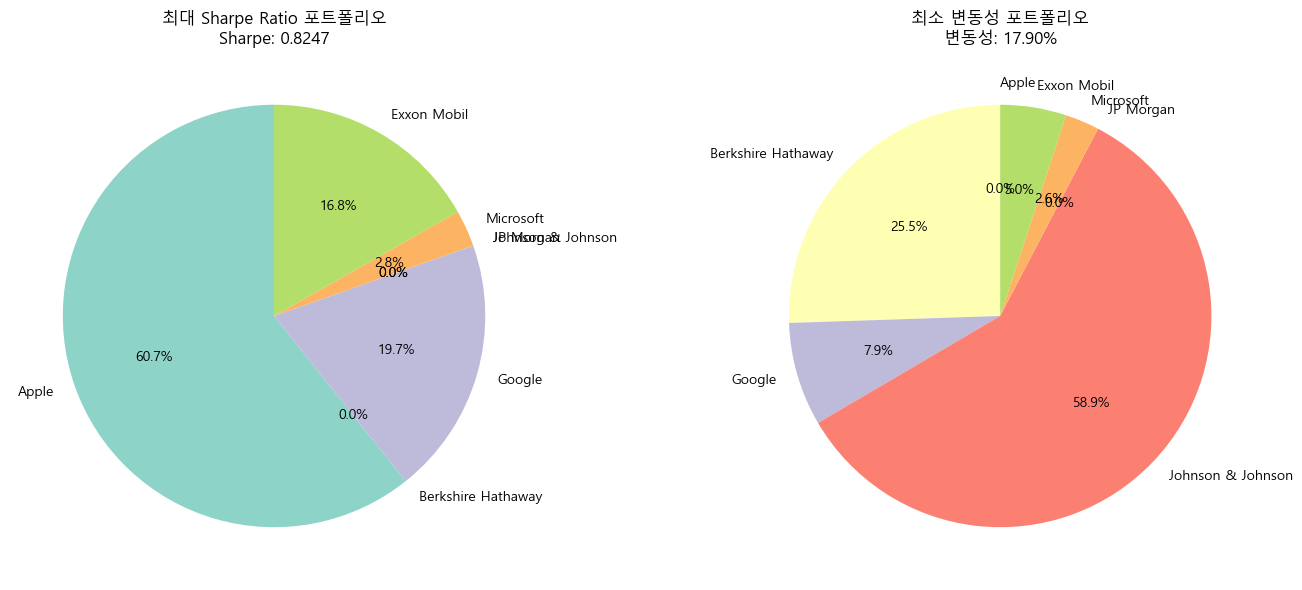

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 최대 Sharpe
axes[0].pie(opt_sharpe.x, labels=df.columns,
            autopct='%1.1f%%', startangle=90,
            colors=plt.cm.Set3.colors[:num_assets])
axes[0].set_title(f'최대 Sharpe Ratio 포트폴리오\nSharpe: {max_sharpe_perf[2]:.4f}', fontsize=12)

# 최소 변동성
axes[1].pie(opt_vol.x, labels=df.columns,
            autopct='%1.1f%%', startangle=90,
            colors=plt.cm.Set3.colors[:num_assets])
axes[1].set_title(f'최소 변동성 포트폴리오\n변동성: {min_vol_perf[1]*100:.2f}%', fontsize=12)

plt.tight_layout()
plt.savefig('images/optimal_portfolios.png', dpi=150, bbox_inches='tight')
plt.show()